# Load multiple data files


It's perfectly fine to manually import multiple datasets. However, there will be times when you'd want to import a bunch of datasets without having to make multiple read_csv() calls. You can use the glob library that is built into Python to look for files that match a pattern. The library is called "glob" because "globbing" is the way patterns are specified in the Bash shell.


In [2]:
import glob
import pandas as pd

# Get a list of all the csv files
csv_files = glob.glob('dataset/*.csv')

# List comprehension that loads of all the files
dfs = [pd.read_csv(f).shape for f in csv_files]

# List comprehension that looks at the shape of all DataFrames
print(dfs)

[(16, 2), (1458, 8), (153, 6), (122, 18), (336776, 19), (42097, 22), (59, 40), (59, 40), (59, 40), (3322, 9), (244, 7), (26130, 15)]


# Explore


Now that you have a list of DataFrames, let's explore one of them, the planes dataset. Since you have a list of file names and a corresponding list of DataFrames, you can determine that the planes dataset is the third element in dfs.


In [11]:
planes = pd.read_csv("dataset/planes.csv")

# Get the planes DataFrame
# planes = dfs[2]

# Count the frequency of engines in our data
print(planes['engines'].value_counts())

# Look at all planes with >= 3 engines
print(planes.loc[planes['engines'] >= 3])

# Look at all planes with >= 3 engines and <= 100 seats
print(planes[(planes['engines'] >= 3) & (planes['seats'] <= 100)])

2    3288
1      27
4       4
3       3
Name: engines, dtype: int64
     tailnum    year                     type            manufacturer  \
603   N281AT     NaN  Fixed wing multi engine        AIRBUS INDUSTRIE   
1037  N381AA  1956.0  Fixed wing multi engine                 DOUGLAS   
2109  N670US  1990.0  Fixed wing multi engine                  BOEING   
2706  N840MQ  1974.0  Fixed wing multi engine            CANADAIR LTD   
2764  N854NW  2004.0  Fixed wing multi engine                  AIRBUS   
2771  N856NW  2004.0  Fixed wing multi engine                  AIRBUS   
2931  N905FJ  1986.0  Fixed wing multi engine  AVIONS MARCEL DASSAULT   

                   model  engines  seats  speed         engine  
603             A340-313        4    375    NaN      Turbo-jet  
1037              DC-7BF        4    102  232.0  Reciprocating  
2109             747-451        4    450    NaN      Turbo-jet  
2706               CF-5D        4      2    NaN      Turbo-jet  
2764            A330-2

# Visualize


It's interesting to see that there are so few planes with three or more engines and 100 or less seats. What is even more interesting is that there is a plane with 4 engines and 2 seats. Turns out this is a fighter jet.

If you plotted this data, you would quickly be able to see how common or unusual data are. Here you'll use the pandas plotting methods to do a quick exploratory plot.


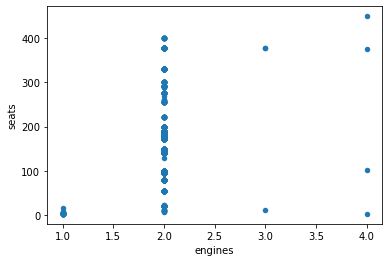

In [12]:
import matplotlib.pyplot as plt

# Scatter plot of engines and seats
planes.plot(x='engines', y='seats', kind='scatter')
plt.show()

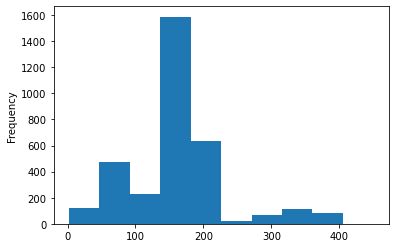

In [13]:
import matplotlib.pyplot as plt

# Histogram of seats
planes['seats'].plot(kind='hist')
plt.show()

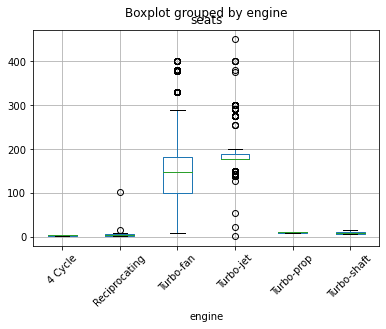

In [14]:
import matplotlib.pyplot as plt

# Boxplot of seats by engine
planes.boxplot(column='seats', by='engine')
plt.xticks(rotation=45)
plt.show()

# Recode dates


Now let's look at another dataset in the nycflights13 datasets, specifically the flights dataset. This dataset gives us the time when a particular flight departed from one of the New York City airports (JFK, LGA, EWR), it's scheduled departure and arrival times, and the departure and arrival delays. You'll begin by investigating to determine if there are any seasonal patterns for delays.


In [8]:
import numpy as np

flights = pd.read_csv("dataset/flights.csv")
def calculate_season(month, day):
    if month < 3:
        return('winter')
    elif month == 3:
        if day < 20:
            return('winter')
        else:
            return('spring')
    elif month < 6:
        return('spring')
    elif month == 6:
        if day < 21:
            return('spring')
        else:
            return('summer')
    elif month < 9:
        return('summer')
    elif month == 9:
        if day < 22:
            return('summer')
        else:
            return('fall')
    elif month < 12:
        return('fall')
    elif month == 12:
        if day < 21:
            return('fall')
        else:
            return('winter')
    else:
        return(np.NaN)
    
def get_season(time_hour):
    y_m_dt = time_hour.split('-')
    month = int(y_m_dt[1])
    
    d_t = y_m_dt[2].split(' ')
    day = int(d_t[0])
    return(calculate_season(month, day))

# Print time_hour
print(flights['time_hour'])

# Apply the function on data
flights['season'] = flights['time_hour'].apply(get_season)

# Print time_hour and season
print(flights[['time_hour' , 'season']])

0         2013-01-01 05:00:00
1         2013-01-01 05:00:00
2         2013-01-01 05:00:00
3         2013-01-01 05:00:00
4         2013-01-01 06:00:00
                 ...         
336771    2013-09-30 14:00:00
336772    2013-09-30 22:00:00
336773    2013-09-30 12:00:00
336774    2013-09-30 11:00:00
336775    2013-09-30 08:00:00
Name: time_hour, Length: 336776, dtype: object
                  time_hour  season
0       2013-01-01 05:00:00  winter
1       2013-01-01 05:00:00  winter
2       2013-01-01 05:00:00  winter
3       2013-01-01 05:00:00  winter
4       2013-01-01 06:00:00  winter
...                     ...     ...
336771  2013-09-30 14:00:00    fall
336772  2013-09-30 22:00:00    fall
336773  2013-09-30 12:00:00    fall
336774  2013-09-30 11:00:00    fall
336775  2013-09-30 08:00:00    fall

[336776 rows x 2 columns]


# Groupby aggregates


Now let's look for some patterns in the data. One way you can do this is to look at groupby aggregates of the data. You will see if delays vary with season, carrier and origin airport.


In [15]:
# Calculate total_delay
flights['total_delay'] = flights['dep_delay'] + flights['arr_delay']

# Mean total_delay by carrier
tdel_car = flights.groupby('carrier')['total_delay'].mean().reset_index()
print(tdel_car)

# Mean dep_delay and arr_delay for each season
dadel_season = flights.groupby('season')['dep_delay', 'arr_delay'].mean().reset_index()
print(dadel_season)

# Mean and std delays by origin
del_ori = flights.groupby('origin')['total_delay', 'dep_delay', 'arr_delay'].agg(['mean', 'std'])
print(del_ori)

   carrier  total_delay
0       9E    23.819244
1       AA     8.933421
2       AS    -4.100141
3       B6    22.425521
4       DL    10.868291
5       EV    35.635360
6       F9    42.121880
7       FL    38.721890
8       HA    -2.014620
9       MQ    21.220114
10      OO    24.517241
11      UA    15.574920
12      US     5.874288
13      VX    14.521110
14      WN    27.310777
15      YV    34.455882
   season  dep_delay  arr_delay
0    fall   7.939662   3.091086
1  spring  13.402534   7.292506
2  summer  16.625480   9.854076
3  winter  12.382694   7.241457
       total_delay             dep_delay            arr_delay           
              mean        std       mean        std      mean        std
origin                                                                  
EWR      24.116165  85.135466  15.107954  41.323704  9.107055  45.529183
JFK      17.575088  81.050496  12.112159  39.035071  5.551481  44.277448
LGA      16.070071  81.937556  10.346876  39.993021  5.783488  43.8

C:\Users\88016\AppData\Local\Temp/ipykernel_7548/548467352.py:9: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  dadel_season = flights.groupby('season')['dep_delay', 'arr_delay'].mean().reset_index()
C:\Users\88016\AppData\Local\Temp/ipykernel_7548/548467352.py:13: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  del_ori = flights.groupby('origin')['total_delay', 'dep_delay', 'arr_delay'].agg(['mean', 'std'])


# Plots


You will now create a figure in which you can visualize the departure delay by origin and the average total delay by carrier.


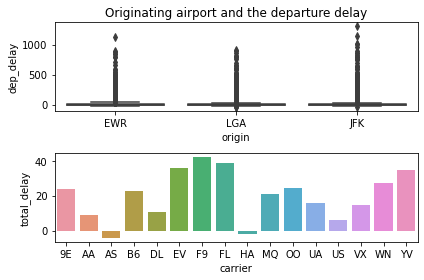

In [17]:
import seaborn as sns
# Create a figure
fig, (ax1, ax2) = plt.subplots(2,1)

# Boxplot and barplot in the axes
sns.boxplot(x='origin', y='dep_delay', data=flights, ax=ax1)
sns.barplot(x='carrier', y='total_delay', data=tdel_car, ax=ax2)

# Label axes
ax1.set_title('Originating airport and the departure delay')

# Use tight_layout() so the plots don't overlap
fig.tight_layout()
plt.show()

# Dummy variables


In the last exercise of the course, you will prepare your data for modeling by dummy encoding your non-numeric columns. For example, if you have a column of gender values, 'Male' and 'Female', you want separate columns that tell you whether the observation is from a 'Male' or a 'Female'. This process of creating dummy variables is also called one-hot encoding.

You can use the get_dummies() function from pandas to convert the non-numeric columns into dummy variables.


In [18]:
flights_sub = pd.read_csv("dataset/flights_sample.csv")
# Look at the head of flights_sub
print(flights_sub.head())

# Create dummy variables
flights_dummies = pd.get_dummies(flights_sub)

# Look at the head of flights_dummies
print(flights_dummies.head())

   Unnamed: 0  year  month  day  dep_time  sched_dep_time  dep_delay  \
0       46590  2013     10   22     630.0             630        0.0   
1      220488  2013      5   30     918.0             925       -7.0   
2      226972  2013      6    6     827.0             835       -8.0   
3      251790  2013      7    2    1201.0            1035       86.0   
4      176650  2013      4   13     629.0             630       -1.0   

   arr_time  sched_arr_time  arr_delay  ... tailnum  origin dest air_time  \
0     852.0             838       14.0  ...  N612JB     JFK  MSY    183.0   
1    1054.0            1110      -16.0  ...  N4XJAA     LGA  STL    124.0   
2    1003.0            1020      -17.0  ...  N711MQ     LGA  CLE     72.0   
3    1521.0            1350       91.0  ...  N3CWAA     LGA  MIA    175.0   
4     832.0             832        0.0  ...  N566UW     LGA  CLT     90.0   

  distance  hour  minute            time_hour  season total_delay  
0     1182     6      30  2013-10-22